# <span style="color:Blue">Assignment-4 of COSC5806: Data Analysis with Python</span>

# <span style="color:Blue">Due date: Friday, March 13, 2026, @11:59 PM</span>
# <span style="color:Blue">Cut-off date: Sunday, March 15, 2026, @11:59 PM</span>

## <span style="color:Purple">You are allowed to use core Python's built in modules/packages/libraries, NumPy, Pandas, scikit-learn, matplotlib, and Seaborn. Please read the instruction carefully and do not hesitate to contact me if you have any questions.</span>

### <span style="color:Red">Examples and Resources for this assignment:</span>
<ul>
    <li><span style="color:Red">Chapters 3, 4, 5, 6, 7, 8, and 9 from <a href="https://docs.python.org/3/tutorial/index.html">The Python Tutorial</a></span></li>
    <li><span style="color:Red">Chapter 2 from <a href="https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html">Introduction to NumPy</a></span></li>
    <li><span style="color:Red">Chapter 3 from <a href="https://jakevdp.github.io/PythonDataScienceHandbook/02.00-introduction-to-numpy.html">Data Manipulation with Pandas</a></span></li>
    <li><span style="color:Red">Chapter 2 from <a href="https://github.com/ageron/handson-ml3/blob/main/02_end_to_end_machine_learning_project.ipynb">End to End Machine Learning Project</a></span></li>
    <li><span style="color:Red">Chapter 4 from <a href="https://github.com/ageron/handson-ml3/blob/main/04_training_linear_models.ipynb">Training Linear Models</a></span></li>
</ul>

### <span style="color:Green">Context</span>
The attached CSV file contains daily weather data for the year 2024 for the city of Toronto, Ontario, Canada. It includes key meteorological variables such as:

<ul>
    <li><span><b>Date:</b> The recorded date of the weather data.</span></li>
    <li><span><b>Mean Temp ($^{\circ}$C):</b> The average daily temperature in degrees Celsius.</span></li>
    <li><span><b>Total Precip (mm):</b> The total daily precipitation (rain and melted snow) in millimeters.</span></li>
    <li><span><b>Snowfall (cm):</b> The amount of snowfall in centimeters.</span></li>
    <li><span><b>Wind Speed (km/h):</b> The recorded daily wind speed in kilometers per hour.</span></li>
</ul>

The following <a href="https://climate.weather.gc.ca/glossary_e.html">link</a> might be useful for the description of the features. With this dataset predict the mean temperature of a day.

In [1]:
# checking the versions of the libraries and the version of python being used in the environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Seaborn version:", sns.__version__)
print("Scikit-learn version:", sklearn.__version__)

Pandas version: 2.2.3
NumPy version: 2.2.6
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1


# <span style="color:Green">P1: Load the dataset.</span>

In [2]:
#loading the dataset we using the pandas library to read the csv file and store it in a dataframe called df
df=pd.DataFrame(pd.read_csv(r"C:\Users\MSI\Desktop\Toronto_Weather_Prediction\Data\out.csv"))

# <span style="color:Green">P2: Print a quick description of the data.</span>

In [3]:
#we used the method head() to display the first 5 rows of the dataframe to get an overview of the data
#we used the method info() to get information about the dataframe, including the number of non-null values and the data types of each column
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1826 entries, 0 to 1825
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Longitude (x)              1826 non-null   float64
 1   Latitude (y)               1826 non-null   float64
 2   Station Name               1826 non-null   object 
 3   Climate ID                 1826 non-null   int64  
 4   Date/Time                  1826 non-null   object 
 5   Year                       1826 non-null   int64  
 6   Month                      1826 non-null   int64  
 7   Day                        1826 non-null   int64  
 8   Data Quality               0 non-null      float64
 9   Max Temp (°C)              1818 non-null   float64
 10  Max Temp Flag              8 non-null      object 
 11  Min Temp (°C)              1818 non-null   float64
 12  Min Temp Flag              8 non-null      object 
 13  Mean Temp (°C)             1818 non-null   float

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-79.4,43.67,TORONTO CITY,6158355,2021-01-01,2021,1,1,NaN,2.5,...,NaN,NaN,6.8,NaN,NaN,NaN,NaN,M,NaN,M
1,-79.4,43.67,TORONTO CITY,6158355,2021-01-02,2021,1,2,NaN,2.2,...,NaN,NaN,10.8,NaN,0.0,NaN,NaN,M,NaN,M
2,-79.4,43.67,TORONTO CITY,6158355,2021-01-03,2021,1,3,NaN,2.1,...,NaN,NaN,1.7,NaN,0.0,NaN,NaN,M,NaN,M
3,-79.4,43.67,TORONTO CITY,6158355,2021-01-04,2021,1,4,NaN,1.7,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
4,-79.4,43.67,TORONTO CITY,6158355,2021-01-05,2021,1,5,NaN,1.6,...,NaN,NaN,0.4,NaN,NaN,NaN,NaN,M,NaN,M


# <span style="color:Green">P3: Display a summary of the numerical attributes.</span>

In [4]:
#we use the method describe() to get a statistical summary of the numerical columns in the dataframe, including count, mean, standard deviation, minimum, and maximum values
df.describe()

,Longitude (x),Latitude (y),Climate ID,Year,Month,Day,Data Quality,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
count,1826.000000,1826.000000,1.826000e+03,1826.000000,1826.000000,1826.000000,0.0,1818.000000,1818.000000,1818.000000,1818.000000,1818.000000,364.000000,364.000000,1818.000000,411.000000,286.000000,286.000000
mean,-79.445975,43.671999,6.158430e+06,2023.000548,6.523549,15.727820,NaN,14.355116,6.413091,10.387624,8.826403,1.214026,1.690110,0.482418,2.208966,6.175182,24.667832,48.017483
std,0.092006,0.004000,1.504103e+02,1.414407,3.449478,8.801735,NaN,10.642347,9.555579,9.988180,8.549858,2.284929,5.516378,1.978735,6.026428,8.973047,8.422077,12.866237
min,-79.630000,43.670000,6.158355e+06,2021.000000,1.000000,1.000000,NaN,-12.600000,-20.500000,-16.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,31.000000
25%,-79.400000,43.670000,6.158355e+06,2022.000000,4.000000,8.000000,NaN,5.100000,-0.500000,2.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,22.000000,37.000000
50%,-79.400000,43.670000,6.158355e+06,2023.000000,7.000000,16.000000,NaN,14.550000,6.400000,10.300000,7.700000,0.000000,0.000000,0.000000,0.000000,3.000000,27.000000,45.000000
75%,-79.400000,43.670000,6.158355e+06,2024.000000,10.000000,23.000000,NaN,24.000000,15.000000,19.500000,15.700000,1.500000,0.200000,0.000000,1.300000,8.000000,31.000000,55.750000
max,-79.400000,43.680000,6.158731e+06,2025.000000,12.000000,31.000000,NaN,36.000000,24.800000,30.200000,34.500000,12.200000,48.100000,17.000000,83.600000,50.000000,36.000000,103.000000


# <span style="color:Green">P4: Plot a histogram for each numerical attribute.</span>

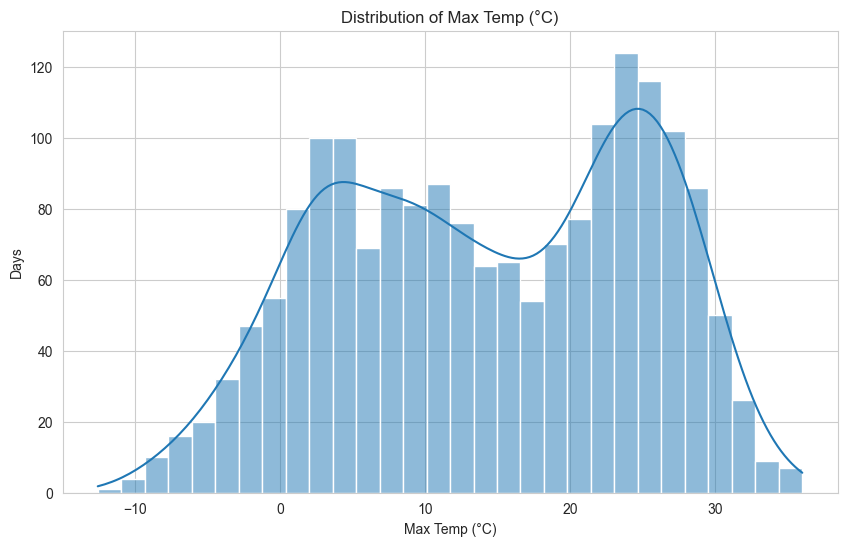

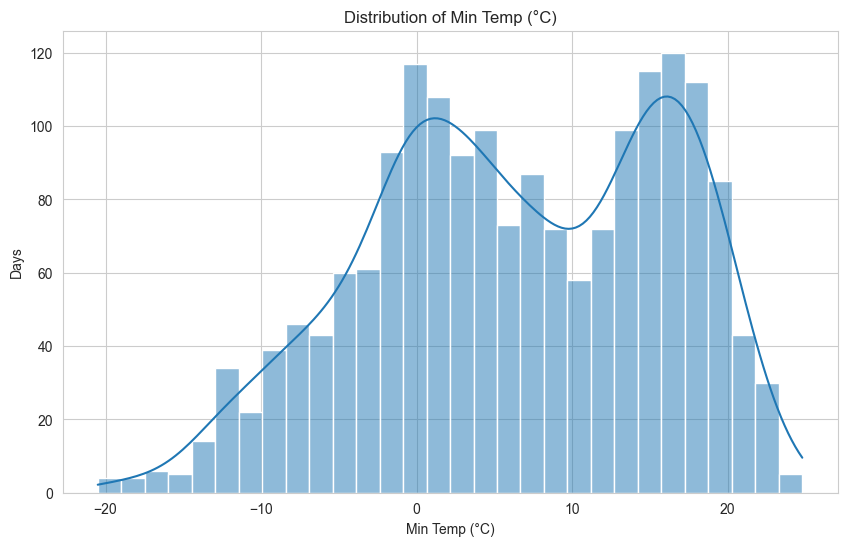

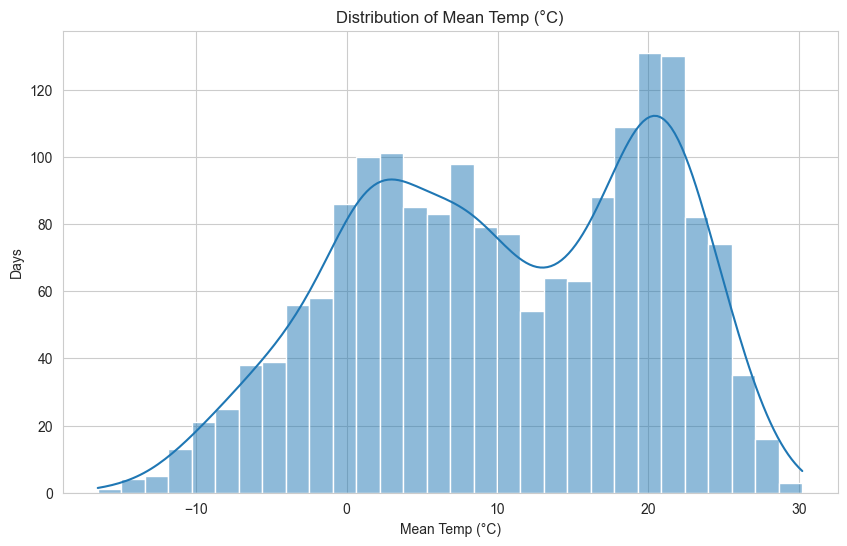

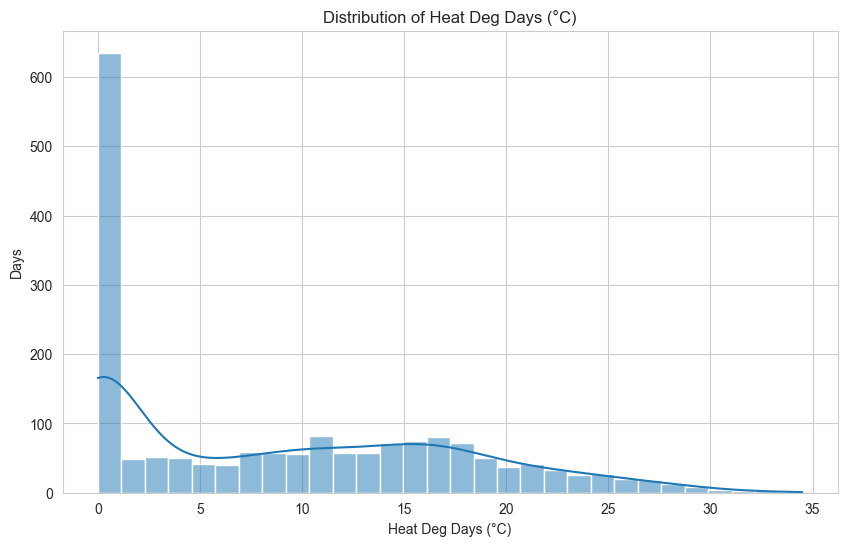

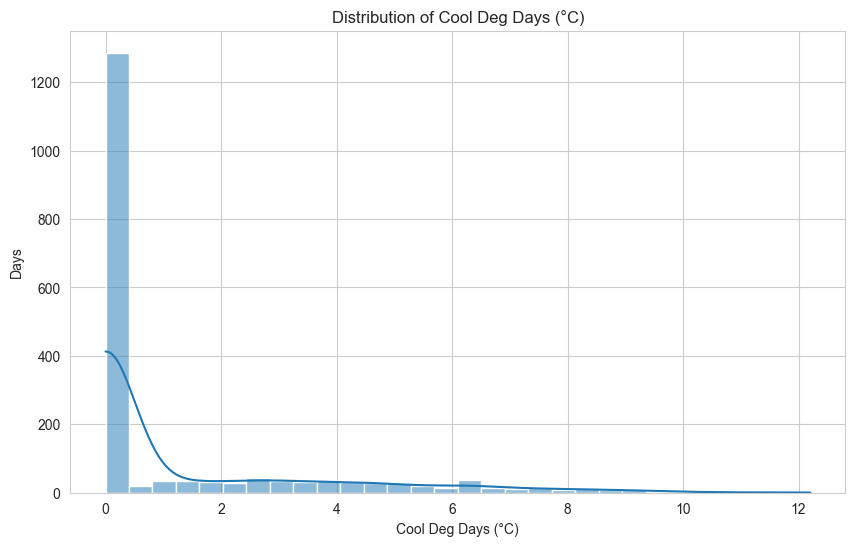

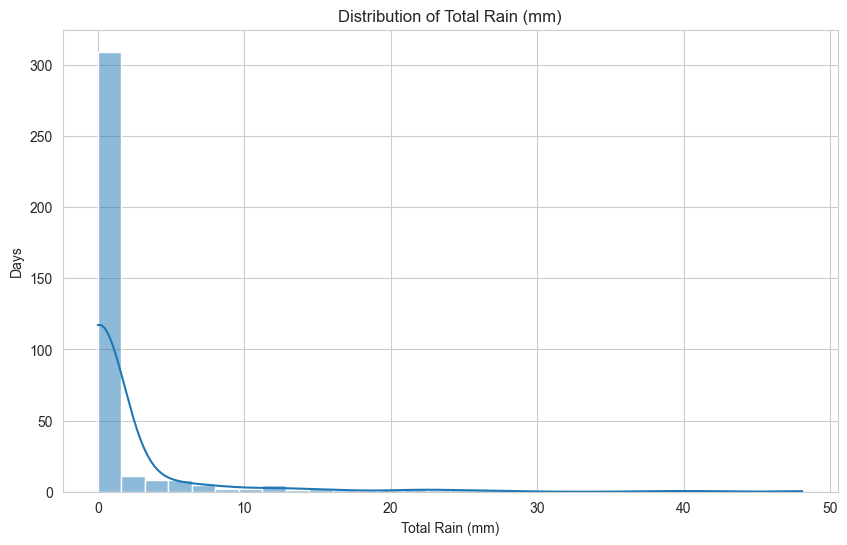

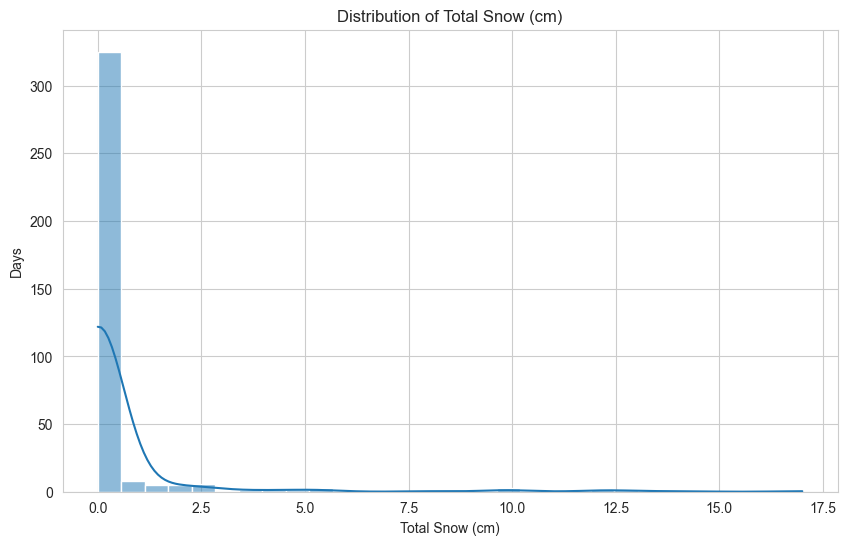

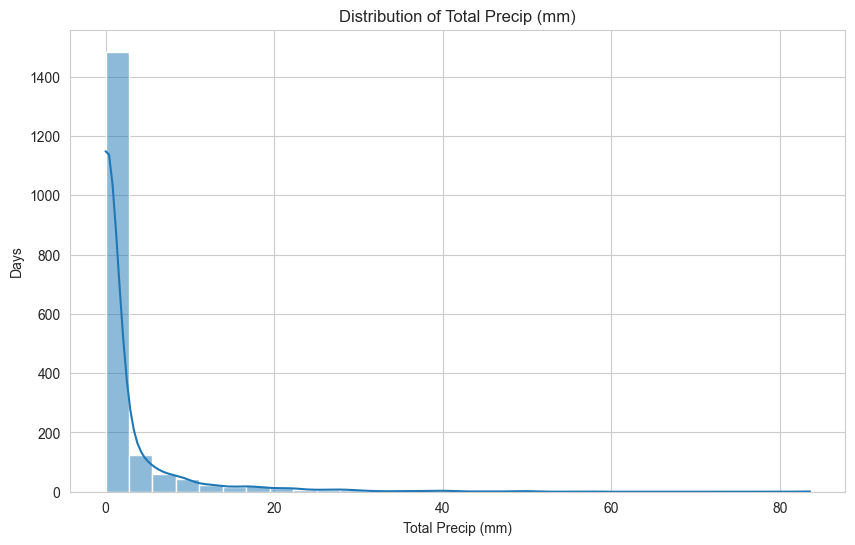

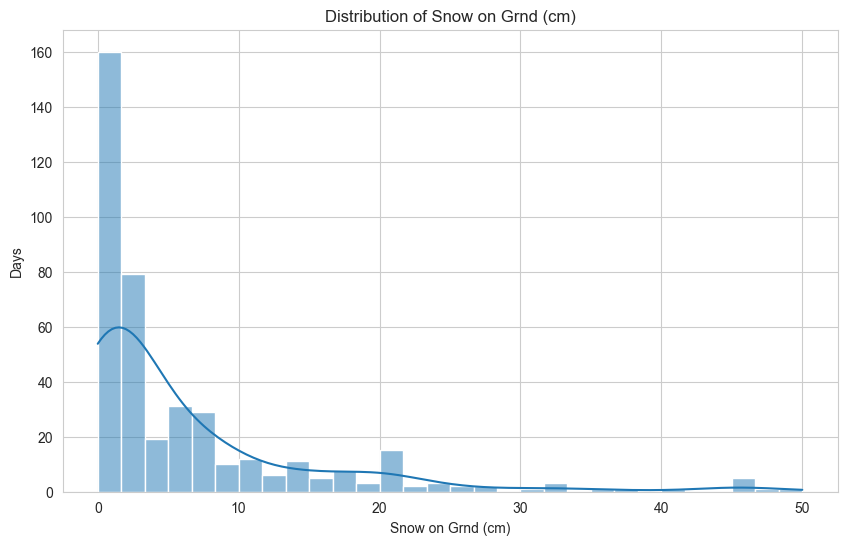

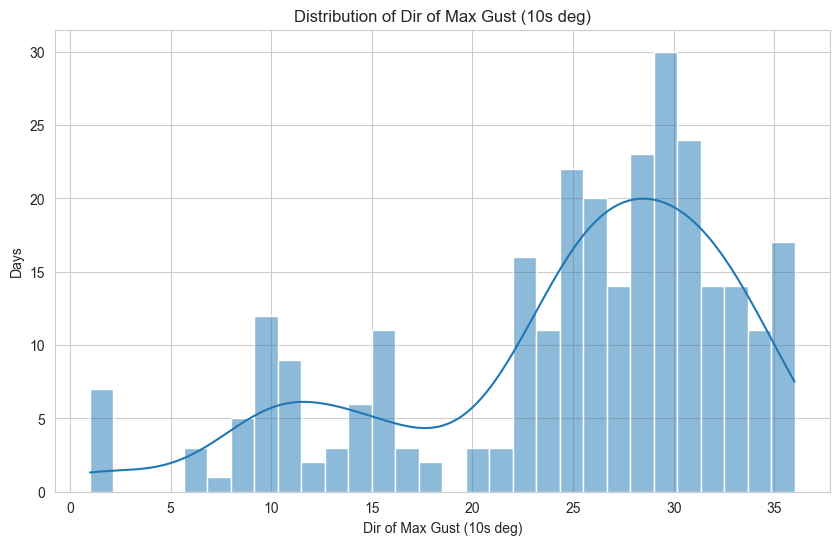

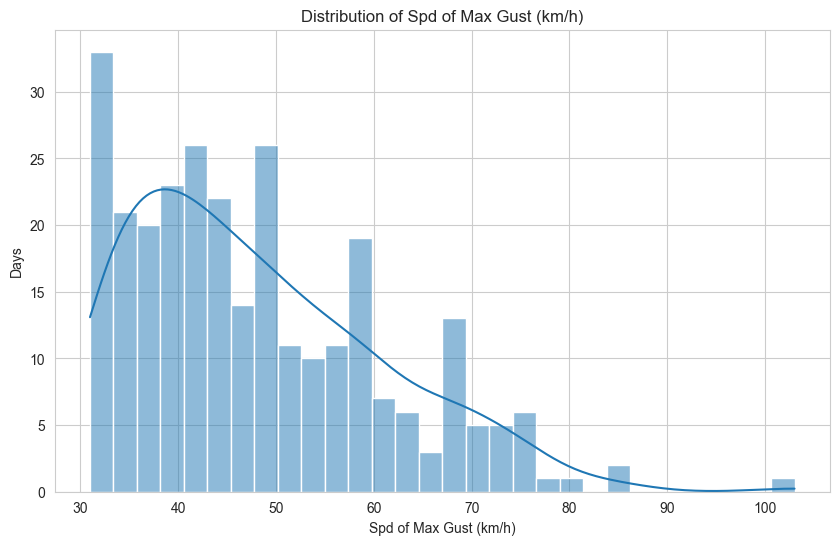

In [5]:
#we are taking the numerical columns and using seaborn to create histograms for each numerical column to visualize the distribution of the data.
# We set the style to "whitegrid" for better aesthetics and specify the figure size.
# We also add a kernel density estimate (kde) to the histogram for a smoother representation of the distribution.
# Finally, we set the title and labels for each plot and display them.
num_cols=df.select_dtypes(include=["float64","int64"]).columns
nums_cols = num_cols.drop(["Longitude (x)", "Latitude (y)", "Climate ID", "Date/Time","Year","Month","Day","Data Quality",""], errors='ignore')
for col in nums_cols:
  sns.set_style("whitegrid")
  plt.figure(figsize=(10,6))
  sns.histplot(df[col], kde=True, bins=30)
  plt.title(f"Distribution of {col}")
  plt.xlabel(col)
  plt.ylabel("Days")
  plt.show()
    



# <span style="color:Green">P5: Compute the standard correlation coefficient (also called Pearson’s r) between every pair of attributes.</span>

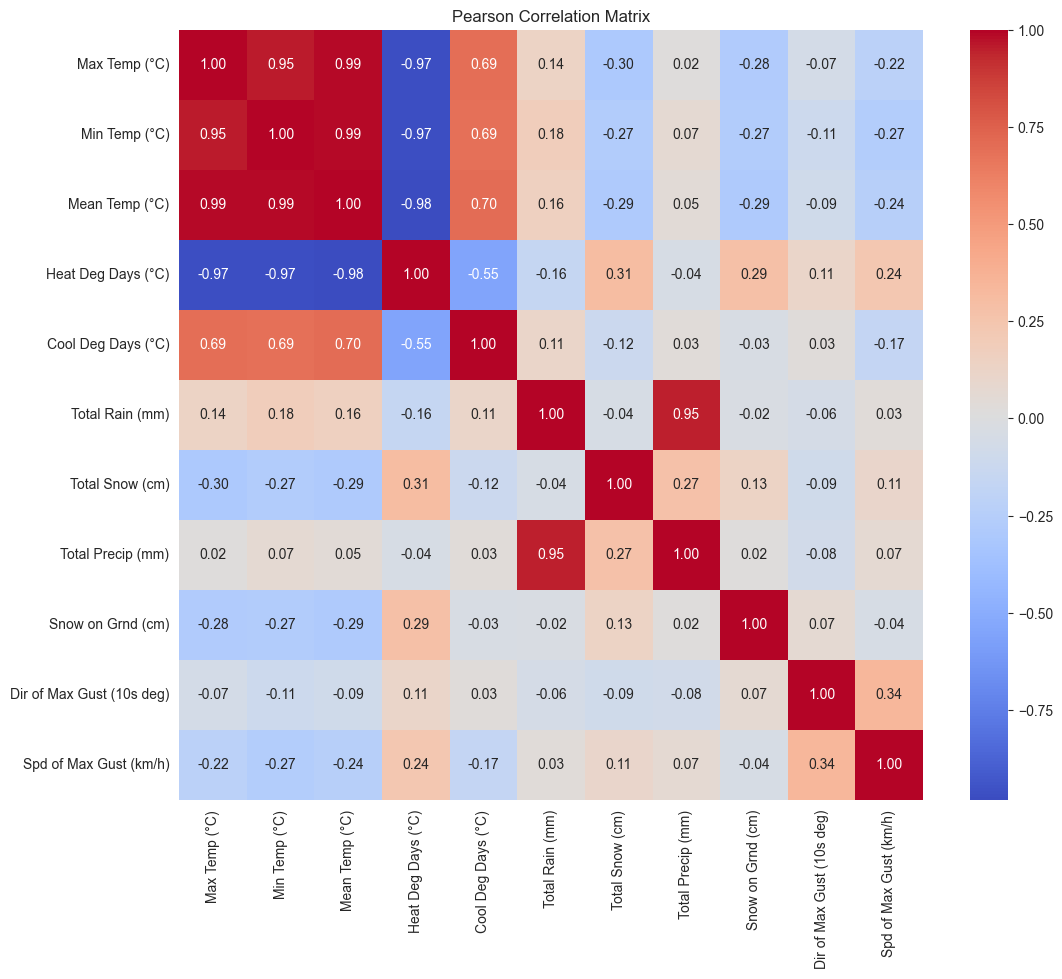

In [6]:
#we transform it into a new DataFrame that contains only the numerical columns we want to analyze for correlation. 
#We then use the corr() method to compute the Pearson correlation matrix for these columns.
df_nums = df[nums_cols]
# Compute correlation on the DataFrame slice
corr_matrix = df_nums.corr(method='pearson')
# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Pearson Correlation Matrix")
plt.show()


# <span style="color:Green">P6: Set the missing values to the median (if any).</span>

In [7]:
df.isna().sum()
#we check for missing values in the numerical columns and fill them with the median value of each column to handle the missing data.
for col in nums_cols:
  median_value=df[col].median()
  df[col].fillna(median_value, inplace=True)
print("Missing values Test :")
print(df[nums_cols].isnull().sum())

Missing values Test :
Max Temp (°C)                0
Min Temp (°C)                0
Mean Temp (°C)               0
Heat Deg Days (°C)           0
Cool Deg Days (°C)           0
Total Rain (mm)              0
Total Snow (cm)              0
Total Precip (mm)            0
Snow on Grnd (cm)            0
Dir of Max Gust (10s deg)    0
Spd of Max Gust (km/h)       0
dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_5232\2834901914.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
C:\Users\MSI\AppData\Local\Temp\ipykernel_5232\2834901914.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when d

In [8]:
#we check for missing values in the numerical columns and fill them with the median value of each column to handle the missing data.
for col in nums_cols:
  median_value=df_nums[col].median()
  df_nums[col].fillna(median_value, inplace=True)
print("Missing values Test :")
print(df_nums[nums_cols].isnull().sum())

df_nums.head()

Missing values Test :
Max Temp (°C)                0
Min Temp (°C)                0
Mean Temp (°C)               0
Heat Deg Days (°C)           0
Cool Deg Days (°C)           0
Total Rain (mm)              0
Total Snow (cm)              0
Total Precip (mm)            0
Snow on Grnd (cm)            0
Dir of Max Gust (10s deg)    0
Spd of Max Gust (km/h)       0
dtype: int64


C:\Users\MSI\AppData\Local\Temp\ipykernel_5232\1096673497.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_nums[col].fillna(median_value, inplace=True)
C:\Users\MSI\AppData\Local\Temp\ipykernel_5232\1096673497.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_nums[col].fillna(median_value, inplace=True)
C:\Users\MSI\AppData\Local\Te

,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg),Spd of Max Gust (km/h)
0,2.5,-1.0,0.7,17.3,0.0,0.0,0.0,6.8,3.0,27.0,45.0
1,2.2,-0.9,0.7,17.3,0.0,0.0,0.0,10.8,0.0,27.0,45.0
2,2.1,0.2,1.1,16.9,0.0,0.0,0.0,1.7,0.0,27.0,45.0
3,1.7,-0.1,0.8,17.2,0.0,0.0,0.0,0.0,3.0,27.0,45.0
4,1.6,0.6,1.1,16.9,0.0,0.0,0.0,0.4,3.0,27.0,45.0


# <span style="color:Green">P7: Split your dataset into training set (80%) and test set (20%).</span>

In [9]:
#we convert the "Date/Time" column to a datetime format using pd.to_datetime().
df["Date/Time"]=pd.to_datetime(df["Date/Time"])
df["Year"]=df["Date/Time"].dt.year
years = sorted(df["Year"].unique())

# Split: first 4 years = train, last year = test
train_years = years[:4]
test_years = years[4:]
# Create train and test sets
train_df = df[df["Year"].isin(train_years)]
test_df = df[df["Year"].isin(test_years)]

# Check sizes
print("Train size:", train_df.shape)
print("Test size:", test_df.shape)
print(train_df["Year"].value_counts())
print(test_df["Year"].value_counts())

Train size: (1461, 31)
Test size: (365, 31)
Year
2024    366
2021    365
2022    365
2023    365
Name: count, dtype: int64
Year
2025    365
Name: count, dtype: int64


# <span style="color:Green">P8: Use LinearRegression, DecisionTreeRegressor, and RandomForestRegressor to train your model. (apply 5-fold cross validation). For each regression model calculate and print RMSE score. </span>

In [35]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Select numeric columns (exclude non-feature columns)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.difference(
    ["Longitude (x)", "Latitude (y)", "Climate ID", "Year"]
)

# Train/test splits (already done)
X_train = train_df[num_cols].copy()
X_test  = test_df[num_cols].copy()
y_train = train_df["Mean Temp (°C)"]
y_test  = test_df["Mean Temp (°C)"]

# Fill missing values using median from training data
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col]  = X_test[col].fillna(median_val)  # use same median



scaler = StandardScaler()

# Fit ONLY on training data 
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

# Ensure all features are numeric
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled  = X_test_scaled.astype(float)

# Ensure no inf values
X_train_scaled[np.isinf(X_train_scaled)] = np.nan
X_test_scaled[np.isinf(X_test_scaled)] = np.nan

# Fill any NaNs just in case (should be zero)
#X_train_scaled = np.nan_to_num(X_train_scaled, nan=np.nanmedian(X_train_scaled))
#X_test_scaled  = np.nan_to_num(X_test_scaled, nan=np.nanmedian(X_train_scaled))

# List of models
models = {
    #"Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, min_samples_leaf=3, min_samples_split=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 5-fold cross-validation
tscv = TimeSeriesSplit(n_splits=5)

for name, model in models.items():
    # Cross-validated RMSE
    neg_rmse_scores = cross_val_score(
        model, X_train_scaled, y_train, 
        scoring='neg_root_mean_squared_error', 
        cv=tscv
    )
    cv_rmse_scores = -neg_rmse_scores
    mean_cv_rmse = np.mean(cv_rmse_scores)
    
    # Fit model on full training set for training RMSE
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    print(f"{name} -> Training RMSE: {train_rmse:.3f}, CV RMSE: {mean_cv_rmse:.3f}")




c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\MSI\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Decision Tree -> Training RMSE: 0.192, CV RMSE: 0.320
Random Forest -> Training RMSE: 0.025, CV RMSE: 0.158


In [46]:
# Linear Regression (Ridge) with training and CV RMSE
from sklearn.linear_model import Ridge

# 1️⃣ Select numeric features only (exclude target)
num_cols = df_nums.columns.difference(["Mean Temp (°C)"])
X_train = train_df[num_cols].copy()
y_train = train_df["Mean Temp (°C)"]

# 2️⃣ Fill missing values with median
for col in X_train.columns:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)

# 3️⃣ Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Handle any inf or NaN values safely
X_train_scaled[np.isinf(X_train_scaled)] = np.nan
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)

# 4️⃣ Define Ridge Regression model (alpha is regularization strength)
model_linear = Ridge(alpha=0.05, random_state=42)

# 5️⃣ 5-fold TimeSeries cross-validation for validation RMSE
tscv = TimeSeriesSplit(n_splits=5)
neg_rmse_scores = cross_val_score(
    model_linear, X_train_scaled, y_train,
    scoring='neg_root_mean_squared_error',
    cv=tscv
)
val_rmse_scores = -neg_rmse_scores
mean_val_rmse = np.mean(val_rmse_scores)

# 6️⃣ Fit model on full training set to get training RMSE
model_linear.fit(X_train_scaled, y_train)
y_train_pred = model_linear.predict(X_train_scaled)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# 7️⃣ Print results
print(f"Linear Regression (Ridge) -> Training RMSE: {train_rmse:.3f}, CV RMSE: {mean_val_rmse:.3f}")

Linear Regression (Ridge) -> Training RMSE: 0.017, CV RMSE: 0.020


# <span style="color:Green">P9: Calculate and print RMSE score for the test set. </span>

In [53]:
#Prdict and calulate RMSE for Decision Tree and Random Forest
for name, model in models.items():
    
    # Fit on full training set
    model.fit(X_train_scaled, y_train)
    
    # Evaluate on test set
    y_pred = model.predict(X_test_scaled)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{name} -> RMSE on test set: {test_rmse:.3f}\n")


y_pred = model_linear.predict(X_test_scaled)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Linear Regression Ridge -> RMSE on test set:", test_rmse)

Decision Tree -> RMSE on test set: 0.305

Random Forest -> RMSE on test set: 0.161

Linear Regression Ridge -> RMSE on test set: 0.015920974956820294


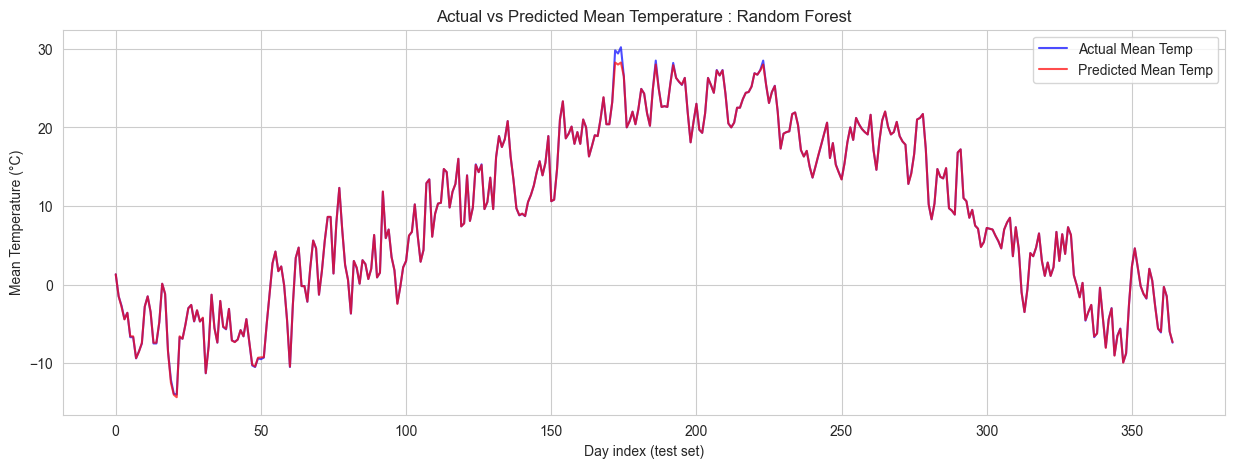

In [48]:
import matplotlib.pyplot as plt

# Predict using your trained model (example: Random Forest)
y_pred = models["Random Forest"].predict(X_test_scaled)

# Plot actual vs predicted
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual Mean Temp", color="blue", alpha=0.7)
plt.plot(y_pred, label="Predicted Mean Temp", color="red", alpha=0.7)
plt.xlabel("Day index (test set)")
plt.ylabel("Mean Temperature (°C)")
plt.title("Actual vs Predicted Mean Temperature : Random Forest")
plt.legend()
plt.show()

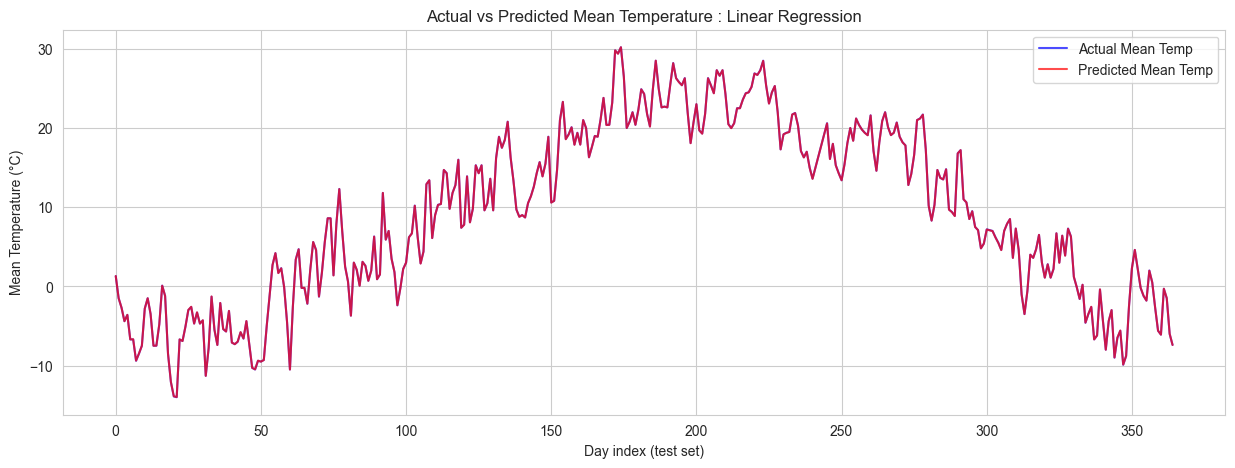

In [50]:
import matplotlib.pyplot as plt

# Predict using your trained model (example: Linear Regression)
y_pred = model_linear.predict(X_test_scaled)

# Plot actual vs predicted
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual Mean Temp", color="blue", alpha=0.7)
plt.plot(y_pred, label="Predicted Mean Temp", color="red", alpha=0.7)
plt.xlabel("Day index (test set)")
plt.ylabel("Mean Temperature (°C)")
plt.title("Actual vs Predicted Mean Temperature : Linear Regression")
plt.legend()
plt.show()

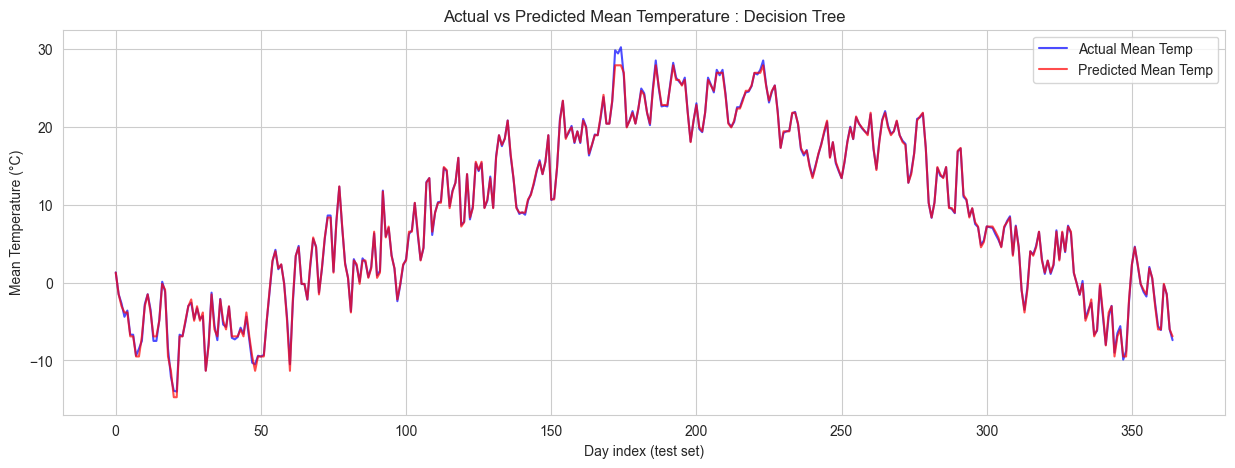

In [51]:
import matplotlib.pyplot as plt

# Predict using your trained model (example: Decision Tree)
y_pred = models["Decision Tree"].predict(X_test_scaled)

# Plot actual vs predicted
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual Mean Temp", color="blue", alpha=0.7)
plt.plot(y_pred, label="Predicted Mean Temp", color="red", alpha=0.7)
plt.xlabel("Day index (test set)")
plt.ylabel("Mean Temperature (°C)")
plt.title("Actual vs Predicted Mean Temperature : Decision Tree")
plt.legend()
plt.show()

# <span style="color:Green">P10: Predict the mean temperature of a date and compare it with the actual mean temperature.</span>

In [52]:
target_date = "2025-06-22" 

# Convert to datetime
target_date = pd.to_datetime(target_date)

# Find the row corresponding to that date
row = test_df[test_df["Date/Time"].dt.date == target_date.date()]


# Extract features and actual value
X_sample = row[num_cols]
y_actual = row["Mean Temp (°C)"].values[0]

# Apply the same scaling
X_sample_scaled = scaler.transform(X_sample)

# Predict using  (Random Forest)
model = models["Random Forest"]  
y_pred = model.predict(X_sample_scaled)[0]

# Print results
print(f"Date: {target_date.date()}")
print(f"Actual Mean Temp: {y_actual:.2f} °C")
print(f"Predicted Mean Temp: {y_pred:.2f} °C")
print(f"Error: {abs(y_actual - y_pred):.2f} °C")

Date: 2025-06-22
Actual Mean Temp: 29.80 °C
Predicted Mean Temp: 28.25 °C
Error: 1.55 °C


### <span style="color:Red">Please submit only your complete Jupyter notebook (.ipynb) file. Do not submit compressed files, entire projects, or any other types of files. Comment your program carefully so that it can be read and understood. If your program is not properly commented, you may lose marks. See \textbf{marking scheme} for details.</span>

### <span style="color:Red">Please note that the submitted work will be considered as your own work and you confirm that you have not received any unauthorized assistance including Large Language Models (LLMs) in preparing for or doing this lab/assignment/examination. You confirm knowing that a mark of 0 may be assigned for entire work.</span>

### <span style="color:Red">You will receive full credits for the working code, otherwise zero. No partial credits!</span>